In [ ]:
import sys, os
print(os.getcwd())
sys.path.append("../src")
from load_nerf_data import load_nerf_data

c:\Users\justs\OneDrive - NTNU\Desktop\semester3\ACIT4030 - 3D Computer\assignment2\acit4030-NeRF\notebooks


In [ ]:
# Load and inspect LEGO dataset
imgs, sils, cams = load_nerf_data("../data/lego", split="train", resize_to=(200, 200))
# Print basic information about the dataset
print(imgs.shape, sils.shape, imgs.min().item(), imgs.max().item())
# Print camera center and background colour
print(cams.get_camera_center()[:3])
print("background colour:", imgs[0][sils[0] < 0.1].mean(0))

Loading transforms_train.json
Using camera_angle_x: 0.691 rad, calculated FOV: 39.598 deg
Loading train split with 50 frames.
Loaded image dimensions: 800x800
Resizing images to: 200x200
Calculated Vertical FOV for camera: 39.598 degrees
torch.Size([50, 200, 200, 3]) torch.Size([50, 200, 200]) -0.23129595816135406 1.201723337173462
tensor([[-1.3875e-07,  2.9394e+00,  2.7586e+00],
        [-3.4310e-07,  2.6945e+00,  2.9982e+00],
        [ 3.7430e-09,  3.3722e+00,  2.2087e+00]])
background colour: tensor([0.0012, 0.0011, 0.0007])


In [ ]:
import json
# Load and inspect LEGO dataset's camera transforms
with open("../data/lego/transforms_train.json") as f:
    t = json.load(f)
for fr in t["frames"][:3]:
    print([row[3] for row in fr["transform_matrix"][:3]])

[2.934088945388794, 0.17724107205867767, 2.7585699558258057]
[2.4656240940093994, -1.0868706703186035, 2.998234272003174]
[-1.054867148399353, -3.202944278717041, 2.2087111473083496]


In [ ]:
import os
# List the files in the poster dataset directory
# Load and inspect the poster dataset
print(os.listdir("../data/poster"))
p_imgs, p_sils, p_cams = load_nerf_data("../data/poster", split="train")
print(p_imgs.shape)
print(p_cams.get_camera_center()[:3])

['base_cam.json', 'colmap', 'images', 'images_2', 'images_4', 'images_8', 'sparse_pc.ply', 'transforms.json']
Using explicit intrinsics from transforms.json (scaled for 1080x1920):
  fl_x=1147.15, fl_y=1158.83, cx=540.00, cy=960.00
Loading train split with 226 frames.
Loaded image dimensions: 1080x1920
Calculated Vertical FOV for camera: 79.278 degrees
Found 'applied_transform' in transforms.json. Applying it to camera poses.
torch.Size([226, 1920, 1080, 3])
tensor([[-2.7469, -0.7096,  2.1471],
        [-2.3388, -0.8357,  2.5229],
        [-2.2730, -0.8823,  2.6418]])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.116789214..1.110137].


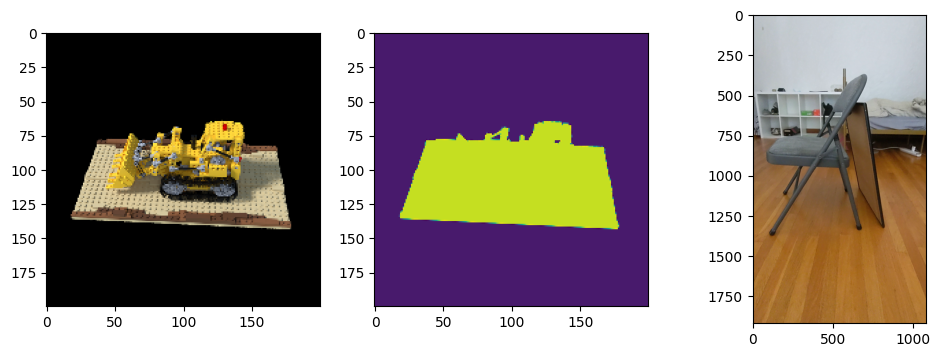

In [ ]:
import matplotlib.pyplot as plt
# Visualize the first image, silhouette, and poster image
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(imgs[0].numpy()); ax[1].imshow(sils[0].numpy()); ax[2].imshow(p_imgs[0].numpy())